# Gaussian Process Model Tutorial

This tutorial covers **GP-specific concepts** in ALF: kernel selection, uncertainty quantification, and Automatic Relevance Determination (ARD).

> **Prerequisites:** This tutorial assumes familiarity with the ALF offline/online design loop.
> See the [offline design tutorial](../offline_design_tutorial.ipynb) for that foundation.
> Here we focus purely on what makes GPs special as surrogate models.

### What you'll learn
1. How to fit a `GPModel` and visualise calibrated uncertainty
2. How different kernels (RBF, Matérn-2.5, Matérn-0.5) behave on the same data
3. How ARD discovers which input dimensions are informative
4. How GP uncertainty guides UCB acquisition in the ALF pipeline

### Environment Setup

From the `/tutorials` directory:
```
uv sync
source .venv/bin/activate
```
Select `.venv` as the kernel when prompted.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from alf_core.dataclasses.candidate import Candidate, Modality
from alf_core.dataclasses.labelled_candidates import LabelledCandidates
from alf_tools.models import FeaturizerConfig, GPModel, GPModelConfig, GPTrainConfig

print("Imports successful")

Imports successful


---
## Section 1: GP Model Deep Dive

We'll fit a GP to a 1D function `sin(x) + sin(2x)` on `[0, 2π]` and explore the
API and visualisations before plugging it into the full ALF pipeline.

In [12]:
np.random.seed(42)

X_MIN, X_MAX = 0.0, 2 * np.pi
N_TRAIN = 25
N_TEST = 200


def true_fn(x):
    return np.sin(x) + np.sin(2 * x)


# Training data — sparse, noisy observations
x_train = np.sort(np.random.uniform(X_MIN, X_MAX, N_TRAIN))
y_train = true_fn(x_train) + np.random.randn(N_TRAIN) * 0.2

# Dense test grid for plotting
x_test = np.linspace(X_MIN, X_MAX, N_TEST)


# Wrap as ALF Candidates
def make_candidates(x_array):
    return [Candidate(data=np.array([xi]), modality=Modality.TABULAR) for xi in x_array]


train_data = LabelledCandidates(make_candidates(x_train), y_train)
test_candidates = make_candidates(x_test)


# Featurizer: list of np.array([xi]) → (n, 1) tensor
def tabular_featurizer(seqs):
    return torch.tensor(np.array(seqs), dtype=torch.float32)


featurizer_config = FeaturizerConfig(
    featurizer_type="custom",
    custom_featurizer=tabular_featurizer,
)

print(f"Training points: {N_TRAIN}")
print(f"Test grid: {N_TEST} points on [0, 2π]")

Training points: 25
Test grid: 200 points on [0, 2π]


In [13]:
# Configure and train RBF GP
model_config = GPModelConfig(kernel_type="rbf", ard=False, mean_type="constant")
train_config = GPTrainConfig(learning_rate=0.1, num_iterations=200, log_frequency=200)

gp_rbf = GPModel(
    name="gp_rbf",
    model_config=model_config,
    train_config=train_config,
    featurizer_config=featurizer_config,
    device="cpu",
)
gp_rbf.train(train_data)

# Predict on test grid
preds = gp_rbf.predict(test_candidates)
mean = preds.means
std = np.sqrt(preds.variances)

print("Learned hyperparameters:")
hp = gp_rbf.get_hyperparameters()
for k, v in hp.items():
    print(f"  {k}: {v}")

Learned hyperparameters:
  noise: 0.05238451063632965
  outputscale: 1.5423636436462402
  lengthscale: 0.8738008737564087
  mean_constant: -0.022589635103940964


/Users/akashsinha/Documents/alf/.venv/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/akashsinha/Documents/alf/core/alf_core/utils/metrics.py:124: UserWarning: num_acquisitions (100) is greater than the numberof available items (25). Using round(12.5)acquisitions instead.
  return metric_fn(means, variances, targets, *args, **kwargs)


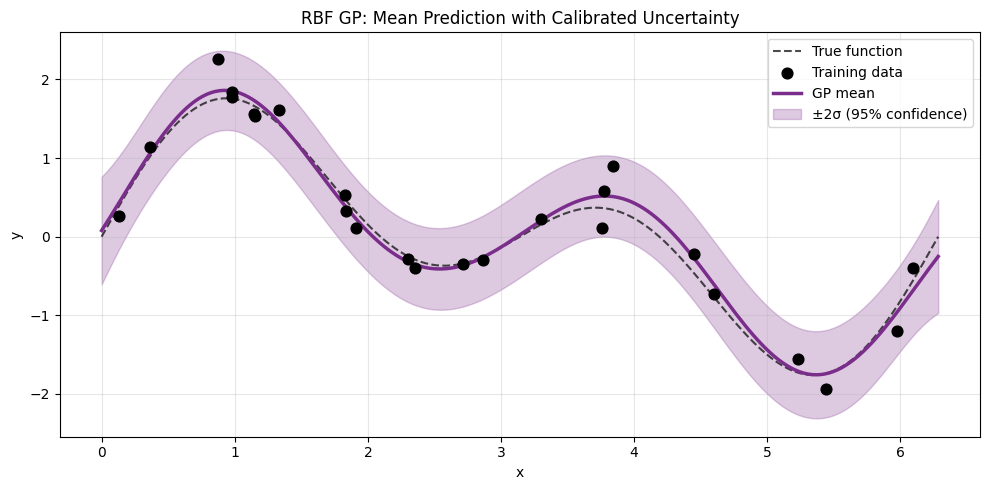

Notice: uncertainty is HIGH in data-sparse regions and COLLAPSES near observations.
This is the key property that makes GPs useful for active learning.


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_test, true_fn(x_test), "k--", linewidth=1.5, label="True function", alpha=0.7)
ax.scatter(x_train, y_train, s=60, color="black", zorder=5, label="Training data")
ax.plot(x_test, mean, color="#7b2d8b", linewidth=2.5, label="GP mean")
ax.fill_between(
    x_test,
    mean - 2 * std,
    mean + 2 * std,
    alpha=0.25,
    color="#7b2d8b",
    label="\u00b12\u03c3 (95% confidence)",
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("RBF GP: Mean Prediction with Calibrated Uncertainty")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: uncertainty is HIGH in data-sparse regions and COLLAPSES near observations.")
print("This is the key property that makes GPs useful for active learning.")

In [15]:
kernels = [
    ("rbf", "RBF (smooth)", "#e74c3c"),
    ("matern", "Mat\u00e9rn-2.5 (moderate)", "#2ecc71"),
    ("matern", "Mat\u00e9rn-0.5 (rough)", "#3498db"),
]
matern_nus = [2.5, 2.5, 0.5]  # nu values; first entry unused (rbf)

fitted = {}
for (ktype, label, _), nu in zip(kernels, matern_nus):
    cfg = GPModelConfig(kernel_type=ktype, matern_nu=nu, ard=False, mean_type="constant")
    gp = GPModel(
        name=f"gp_{label}",
        model_config=cfg,
        train_config=GPTrainConfig(learning_rate=0.1, num_iterations=200, log_frequency=200),
        featurizer_config=featurizer_config,
        device="cpu",
    )
    gp.train(train_data)
    p = gp.predict(test_candidates)
    fitted[label] = (p.means, np.sqrt(p.variances))

print("All kernels fitted.")

All kernels fitted.


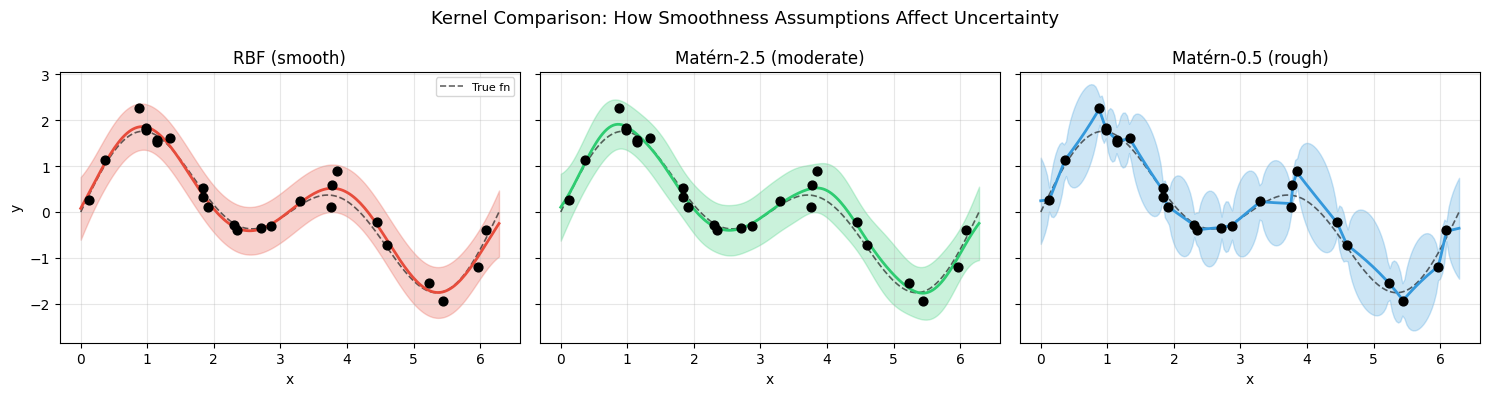


Interpretation:
  RBF         — infinitely differentiable; very smooth predictions.
  Matérn-2.5  — twice differentiable; good default for most functions.
  Matérn-0.5  — non-differentiable (Ornstein-Uhlenbeck); handles rough/discontinuous functions.
Choose based on your prior belief about function smoothness.



In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Kernel Comparison: How Smoothness Assumptions Affect Uncertainty", fontsize=13)

for ax, (ktype, label, color), nu in zip(axes, kernels, matern_nus):
    m, s = fitted[label]
    ax.plot(x_test, true_fn(x_test), "k--", linewidth=1.2, alpha=0.6, label="True fn")
    ax.scatter(x_train, y_train, s=40, color="black", zorder=5)
    ax.plot(x_test, m, color=color, linewidth=2)
    ax.fill_between(x_test, m - 2 * s, m + 2 * s, alpha=0.25, color=color)
    ax.set_title(label)
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("y")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  RBF         — infinitely differentiable; very smooth predictions.
  Mat\u00e9rn-2.5  — twice differentiable; good default for most functions.
  Mat\u00e9rn-0.5  — non-differentiable (Ornstein-Uhlenbeck); handles rough/discontinuous functions.
Choose based on your prior belief about function smoothness.
""")

/Users/akashsinha/Documents/alf/core/alf_core/utils/metrics.py:124: UserWarning: num_acquisitions (100) is greater than the numberof available items (80). Using round(40.0)acquisitions instead.
  return metric_fn(means, variances, targets, *args, **kwargs)


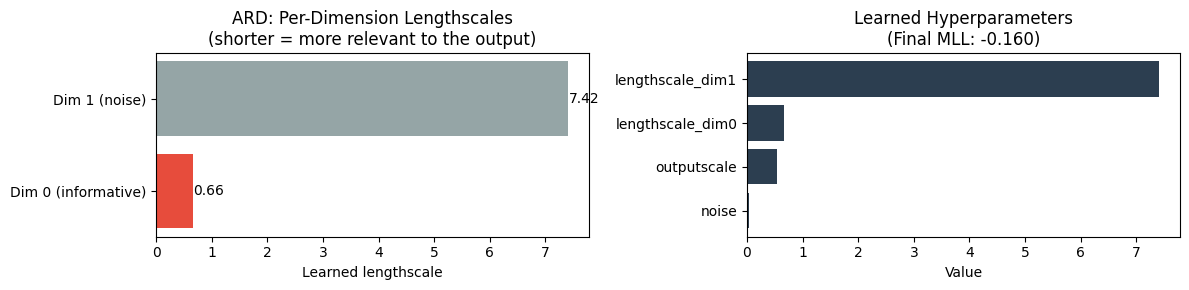

Dim 0 lengthscale: 0.659 (shorter = more relevant)
Dim 1 lengthscale: 7.415 (longer = less relevant)
Final MLL: -0.160  |  Train Pearson: N/A

ARD correctly identifies dim 0 as informative with a shorter lengthscale.


In [17]:
# Generate 2D data where only dim 0 (x) is informative; dim 1 is pure noise
np.random.seed(0)
N = 80
x_2d = np.random.uniform(0, 2 * np.pi, (N, 2))
y_2d = true_fn(x_2d[:, 0]) + np.random.randn(N) * 0.2  # dim 1 irrelevant

candidates_2d = [Candidate(data=x_2d[i], modality=Modality.TABULAR) for i in range(N)]
train_2d = LabelledCandidates(candidates_2d, y_2d)


def featurizer_2d(seqs):
    return torch.tensor(np.array(seqs), dtype=torch.float32)  # (n, 2)


gp_ard = GPModel(
    name="gp_ard",
    model_config=GPModelConfig(kernel_type="rbf", ard=True, mean_type="constant"),
    train_config=GPTrainConfig(learning_rate=0.05, num_iterations=300, log_frequency=300),
    featurizer_config=FeaturizerConfig(featurizer_type="custom", custom_featurizer=featurizer_2d),
    device="cpu",
)
gp_ard.train(train_2d)
hp_ard = gp_ard.get_hyperparameters()

# Plot ARD lengthscales + learned hyperparameter summary
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Left: ARD lengthscale bar chart
lengthscales = hp_ard["lengthscale"].flatten()
min_idx = int(np.argmin(lengthscales))
bar_colors = ["#e74c3c" if i == min_idx else "#95a5a6" for i in range(len(lengthscales))]
bars = axes[0].barh(["Dim 0 (informative)", "Dim 1 (noise)"], lengthscales, color=bar_colors)
axes[0].set_xlabel("Learned lengthscale")
axes[0].set_title("ARD: Per-Dimension Lengthscales\n(shorter = more relevant to the output)")
for bar, val in zip(bars, lengthscales):
    axes[0].text(
        val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=10
    )

# Right: Summary of learned hyperparameters
# Note: GPModel stores only summary metrics (final_mll, not full loss history)
# so we show learned hyperparameter values instead of a training curve
metrics_summary = gp_ard.get_training_summary_metrics()
metric_names = ["noise", "outputscale", "lengthscale_dim0", "lengthscale_dim1"]
metric_vals = [
    hp_ard["noise"],
    hp_ard["outputscale"],
    float(lengthscales[0]),
    float(lengthscales[1]),
]
axes[1].barh(metric_names, metric_vals, color=["#2c3e50"] * 4)
axes[1].set_xlabel("Value")
final_mll = metrics_summary.get("final_mll", float("nan"))
axes[1].set_title(f"Learned Hyperparameters\n(Final MLL: {final_mll:.3f})")
axes[1].axvline(x=0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"Dim 0 lengthscale: {lengthscales[0]:.3f} (shorter = more relevant)")
print(f"Dim 1 lengthscale: {lengthscales[1]:.3f} (longer = less relevant)")
final_mll = metrics_summary.get("final_mll", float("nan"))
print(
    f"Final MLL: {final_mll:.3f}  |  "
    f"Train Pearson: {metrics_summary.get('final_train_pearson', 'N/A')}"
)
print("\nARD correctly identifies dim 0 as informative with a shorter lengthscale.")

---
## Section 2: GP in the ALF Pipeline

Now we plug the GP into a full ALF `DesignTask`. The focus here is on **what GP
uncertainty adds**: UCB uses `score = μ + α·σ` to balance exploitation (high mean)
with exploration (high uncertainty).

For ALF loop mechanics (Oracle, DesignTask, loggers), see the
[offline design tutorial](../offline_design_tutorial.ipynb).

In [18]:
import shutil
from pathlib import Path

from alf_core import (
    BaseDatasetConfig,
    DesignTask,
    FileStateLogger,
    Optimizer,
    Oracle,
    ProtocolSearch,
    SearchProtocol,
    Surrogate,
    TerminalStateLogger,
)
from alf_core.dataclasses.predictions import Predictions
from alf_core.dataset.base_dataset import BaseDataset
from alf_core.model.base_model import BaseModel
from alf_tools.optimizer.acquisition_functions.ucb import UCB


# --- Simulator (online oracle) ---
class SinusoidalSimulator(BaseModel):
    """Evaluates sin(x) + sin(2x) + noise on demand."""

    def __init__(self, noise_std=0.15, seed=42):
        self.rng = np.random.RandomState(seed)
        self.noise_std = noise_std

    def featurise(self, inputs):
        pass

    def train(self, train_data, val_data=None):
        pass

    def predict(self, candidates):
        x = np.array([c.data.flatten()[0] for c in candidates])
        y = true_fn(x) + self.rng.randn(len(x)) * self.noise_std
        return Predictions(means=y)

    def sample(self, *a, **kw):
        raise NotImplementedError

    def get_training_summary_metrics(self):
        return {}


# --- Dataset wrapping initial labelled data ---
INITIAL_N = 20
np.random.seed(42)
x_init = np.sort(np.random.uniform(X_MIN, X_MAX, INITIAL_N))
sim = SinusoidalSimulator()
y_init = sim.predict(make_candidates(x_init)).means
initial_lc = LabelledCandidates(make_candidates(x_init), y_init)


class InitialDataset(BaseDataset):
    def load_dataset(self):
        return initial_lc


dataset = InitialDataset(
    BaseDatasetConfig(
        name="sinusoidal_online",
        modality=Modality.TABULAR,
        seed=42,
        train_ratio=0.8,
        validation_frac=0.2,
        test_ratio=0.0,
        split_type="random",
    )
)
dataset.setup()  # BaseTask.setup() does not call dataset.setup() — must be explicit


# --- Continuous search protocol ---
class ContinuousGridSearch(SearchProtocol):
    def __init__(self, x_min, x_max, n_points=300):
        self.x_min, self.x_max, self.n_points = x_min, x_max, n_points

    def __call__(self, state):
        x = np.linspace(self.x_min, self.x_max, self.n_points)
        return make_candidates(x)


# --- GP surrogate ---
gp_pipeline = GPModel(
    name="gp_pipeline",
    model_config=GPModelConfig(kernel_type="matern", matern_nu=2.5, ard=False),
    train_config=GPTrainConfig(learning_rate=0.1, num_iterations=100, log_frequency=100),
    featurizer_config=featurizer_config,
    device="cpu",
)
surrogate = Surrogate(model=gp_pipeline)
oracle = Oracle(scorer=SinusoidalSimulator(seed=99))
optimizer = Optimizer(
    acquisition_fn=UCB(alpha=0.9),
    search_fn=ProtocolSearch(protocol=ContinuousGridSearch(X_MIN, X_MAX, 300)),
)

print("\u2705 ALF pipeline configured")

✅ ALF pipeline configured


In [19]:
save_path = Path("results/gp_pipeline/")
if save_path.exists():
    shutil.rmtree(save_path)

task = DesignTask(num_acq_rounds=5, acq_batch_size=5)

# setup() only builds the State object — it does NOT train the GP.
# Train explicitly on the initial data to capture round-0 predictions.
state = task.setup(dataset=dataset, surrogate=surrogate)
surrogate.fit(
    train_data=state.dataset.train_dataset,
    val_data=state.dataset.validation_dataset,
)

preds_r0 = gp_pipeline.predict(test_candidates)
mean_r0 = preds_r0.means.copy()
std_r0 = np.sqrt(preds_r0.variances).copy()
x_train_r0 = np.array([c.data.flatten()[0] for c in state.dataset.train_dataset.candidates])
y_train_r0 = state.dataset.train_dataset.labels.copy()

task.run(
    state=state,
    state_loggers=[TerminalStateLogger(), FileStateLogger(output_path=save_path)],
    optimizer=optimizer,
    oracle=oracle,
)
print("✅ 5 acquisition rounds complete")

/Users/akashsinha/Documents/alf/core/alf_core/utils/metrics.py:124: UserWarning: num_acquisitions (100) is greater than the numberof available items (13). Using round(6.5)acquisitions instead.
  return metric_fn(means, variances, targets, *args, **kwargs)
/Users/akashsinha/Documents/alf/core/alf_core/utils/metrics.py:318: RuntimeWarning: invalid value encountered in multiply
  (targets >= means - num_stds * np.sqrt(variances))
/Users/akashsinha/Documents/alf/core/alf_core/utils/metrics.py:319: RuntimeWarning: invalid value encountered in multiply
  & (targets <= means + num_stds * np.sqrt(variances))
/Users/akashsinha/Documents/alf/core/alf_core/utils/metrics.py:124: UserWarning: num_acquisitions (100) is greater than the numberof available items (3). Using round(1.5)acquisitions instead.
  return metric_fn(means, variances, targets, *args, **kwargs)
/Users/akashsinha/Documents/alf/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
 

✅ 5 acquisition rounds complete


/Users/akashsinha/Documents/alf/.venv/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/akashsinha/Documents/alf/core/alf_core/utils/metrics.py:124: UserWarning: num_acquisitions (100) is greater than the numberof available items (33). Using round(16.5)acquisitions instead.
  return metric_fn(means, variances, targets, *args, **kwargs)
/Users/akashsinha/Documents/alf/core/alf_core/utils/metrics.py:124: UserWarning: num_acquisitions (100) is greater than the numberof available items (8). Using round(4.0)acquisitions instead.
  return metric_fn(means, variances, targets, *args, **kwargs)
/Users/akashsinha/Documents/alf/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/akashsinha/Documents/alf/.venv/lib/python3.12/site-packages/numpy/_core/_method

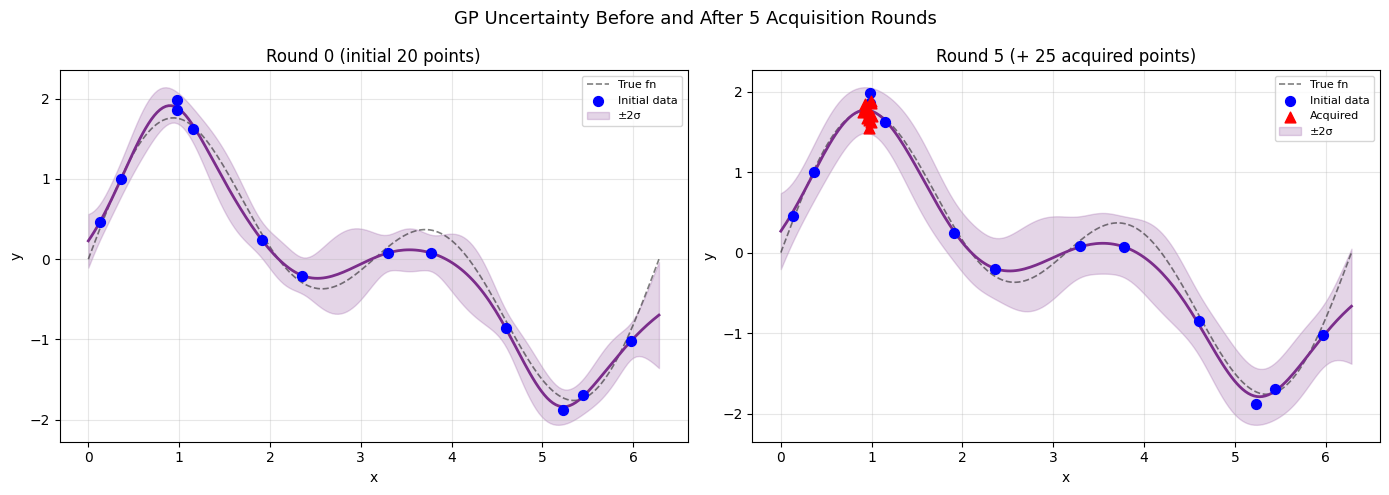

Mean uncertainty — Round 0: 0.148 → Round 5: 0.203
Uncertainty reduced by -37.2%


In [20]:
# Predictions after 5 rounds
preds_r5 = gp_pipeline.predict(test_candidates)
mean_r5 = preds_r5.means
std_r5 = np.sqrt(preds_r5.variances)

# All training data after acquisition
all_x = np.array([c.data.flatten()[0] for c in state.dataset.train_dataset.candidates])
all_y = state.dataset.train_dataset.labels
acquired_x = all_x[INITIAL_N:]
acquired_y = all_y[INITIAL_N:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GP Uncertainty Before and After 5 Acquisition Rounds", fontsize=13)

for ax, (loop_mean, loop_std, title) in zip(
    axes,
    [
        (mean_r0, std_r0, "Round 0 (initial 20 points)"),
        (mean_r5, std_r5, "Round 5 (+ 25 acquired points)"),
    ],
):
    ax.plot(x_test, true_fn(x_test), "k--", linewidth=1.2, alpha=0.5, label="True fn")
    ax.scatter(x_train_r0, y_train_r0, s=50, color="blue", zorder=5, label="Initial data")
    if title.startswith("Round 5"):
        ax.scatter(
            acquired_x, acquired_y, s=60, color="red", marker="^", zorder=5, label="Acquired"
        )
    ax.plot(x_test, loop_mean, color="#7b2d8b", linewidth=2)
    ax.fill_between(
        x_test,
        loop_mean - 2 * loop_std,
        loop_mean + 2 * loop_std,
        alpha=0.2,
        color="#7b2d8b",
        label="\u00b12\u03c3",
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mean_std_r0 = std_r0.mean()
mean_std_r5 = std_r5.mean()
print(f"Mean uncertainty \u2014 Round 0: {mean_std_r0:.3f} \u2192 Round 5: {mean_std_r5:.3f}")
print(f"Uncertainty reduced by {(1 - mean_std_r5 / mean_std_r0) * 100:.1f}%")

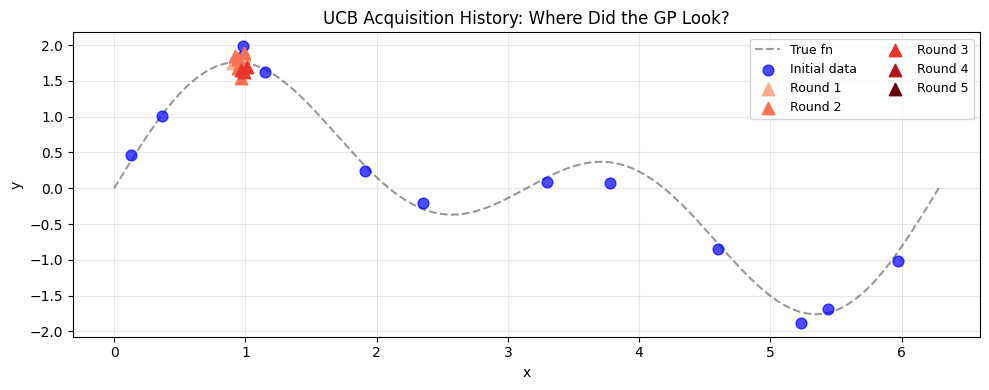

UCB balances: high predicted mean (exploitation) + high uncertainty (exploration).


In [21]:
# all_x, all_y, acquired_x, acquired_y populated in previous cell (Cell 13)
ACQ_BATCH_SIZE = 5
NUM_ROUNDS = 5

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_test, true_fn(x_test), "k--", linewidth=1.5, alpha=0.4, label="True fn")
ax.scatter(x_train_r0, y_train_r0, s=60, color="blue", zorder=5, label="Initial data", alpha=0.7)

colors = plt.cm.Reds(np.linspace(0.3, 1.0, NUM_ROUNDS))
for i in range(NUM_ROUNDS):
    start = INITIAL_N + i * ACQ_BATCH_SIZE
    end = start + ACQ_BATCH_SIZE
    rx = all_x[start:end]
    ry = all_y[start:end]
    ax.scatter(rx, ry, s=80, color=colors[i], marker="^", zorder=6, label=f"Round {i + 1}")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("UCB Acquisition History: Where Did the GP Look?")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("UCB balances: high predicted mean (exploitation) + high uncertainty (exploration).")

In [22]:
if save_path.exists():
    shutil.rmtree(save_path)
print("\u2705 Cleaned up results directory")

✅ Cleaned up results directory


---
## Section 3: 2D Temperature Field

A synthetic non-stationary temperature field to explore GP behaviour in 2D:

$$T(x, y) = 20 + 5 \cdot \exp\!\left(-\frac{(x-2)^2 + (y-3)^2}{2}\right) + 2 \cdot \sin(0.5x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 0.2^2)$$

The Gaussian bump creates a localised hot-spot; the sinusoidal term adds large-scale non-stationarity.

Grid  : 100×100 = 10000 points
Samples: 60 noisy observations
T range (true): [20.01, 26.71] °C


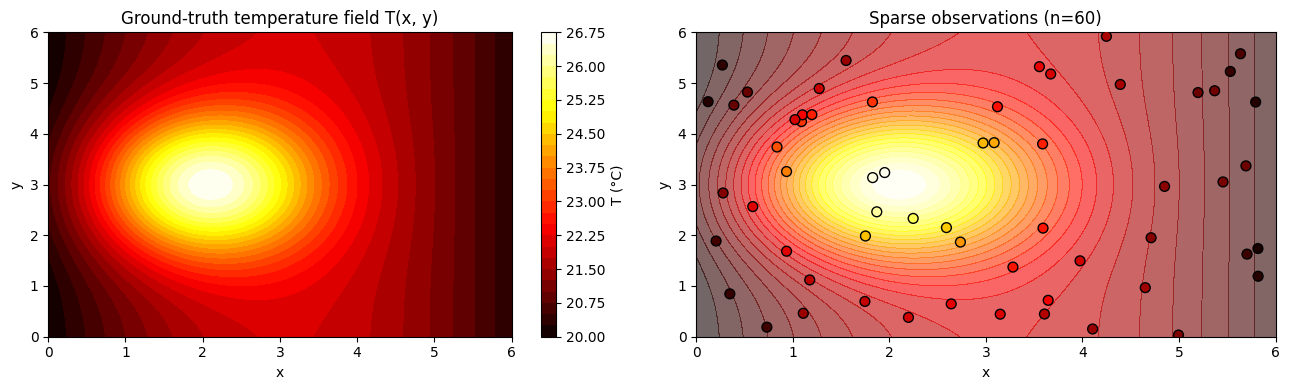

Hot-spot centred at (2, 3); sinusoidal modulation visible along x-axis.


In [23]:
np.random.seed(0)

# Grid extents
X2_MIN, X2_MAX = 0.0, 6.0
Y2_MIN, Y2_MAX = 0.0, 6.0
N_GRID = 100  # points per axis for the dense evaluation grid


def temperature_field(x, y, noise_std=0.0, rng=None):
    """Synthetic 2D temperature: Gaussian hot-spot + sinusoidal trend + optional noise."""
    signal = 20 + 5 * np.exp(-((x - 2) ** 2 + (y - 3) ** 2) / 2) + 2 * np.sin(0.5 * x)
    if noise_std > 0 and rng is not None:
        signal = signal + rng.randn(*np.shape(x)) * noise_std
    return signal


# Dense ground-truth grid (noise-free) for visualisation
xg = np.linspace(X2_MIN, X2_MAX, N_GRID)
yg = np.linspace(Y2_MIN, Y2_MAX, N_GRID)
XX, YY = np.meshgrid(xg, yg)
ZZ_true = temperature_field(XX, YY)

# Sparse noisy training samples
N_SAMPLES = 60
rng = np.random.RandomState(42)
x_samp = rng.uniform(X2_MIN, X2_MAX, N_SAMPLES)
y_samp = rng.uniform(Y2_MIN, Y2_MAX, N_SAMPLES)
z_samp = temperature_field(x_samp, y_samp, noise_std=0.2, rng=rng)

print(f"Grid  : {N_GRID}×{N_GRID} = {N_GRID**2} points")
print(f"Samples: {N_SAMPLES} noisy observations")
print(f"T range (true): [{ZZ_true.min():.2f}, {ZZ_true.max():.2f}] °C")

# --- Visualise ground truth + sample locations ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].contourf(XX, YY, ZZ_true, levels=30, cmap="hot")
fig.colorbar(im, ax=axes[0], label="T (°C)")
axes[0].set_title("Ground-truth temperature field T(x, y)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].contourf(XX, YY, ZZ_true, levels=30, cmap="hot", alpha=0.6)
axes[1].scatter(
    x_samp,
    y_samp,
    c=z_samp,
    cmap="hot",
    edgecolors="k",
    s=50,
    zorder=5,
    vmin=ZZ_true.min(),
    vmax=ZZ_true.max(),
)
axes[1].set_title(f"Sparse observations (n={N_SAMPLES})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

print("Hot-spot centred at (2, 3); sinusoidal modulation visible along x-axis.")

/Users/akashsinha/Documents/alf/.venv/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/akashsinha/Documents/alf/core/alf_core/utils/metrics.py:124: UserWarning: num_acquisitions (100) is greater than the numberof available items (60). Using round(30.0)acquisitions instead.
  return metric_fn(means, variances, targets, *args, **kwargs)


Lengthscale x: nan  |  Lengthscale y: nan
Noise: 0.0323  |  Outputscale: 0.193


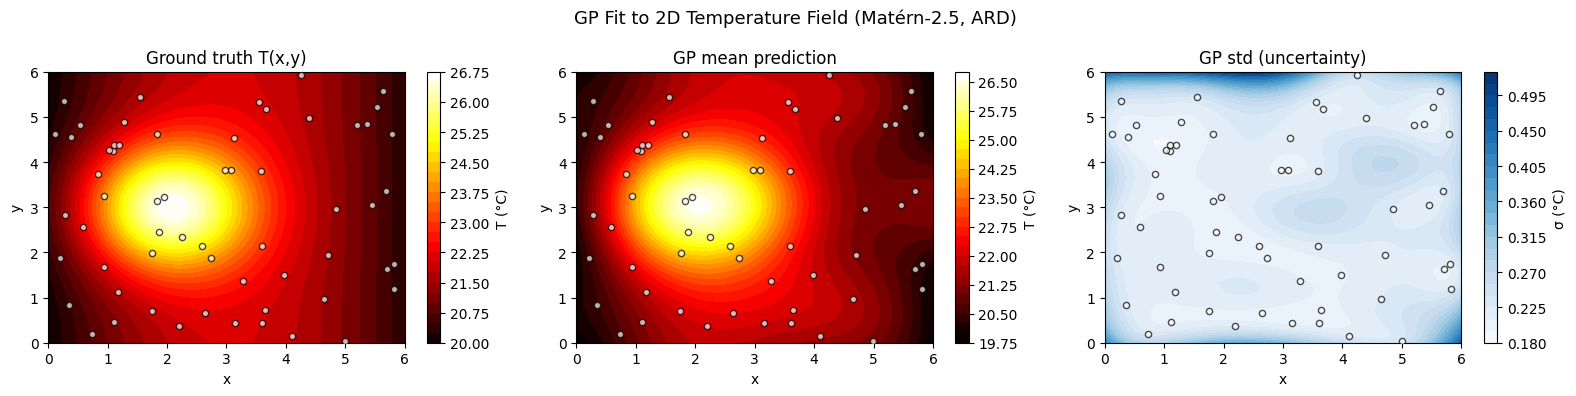

Grid RMSE (GP mean vs truth): 0.1706 °C
Mean predicted std: 0.2371 °C


In [24]:
# Wrap as ALF objects
from functools import partial

import gpytorch

xy_samp = np.stack([x_samp, y_samp], axis=1)  # (N, 2)
candidates_temp = [Candidate(data=xy_samp[i], modality=Modality.TABULAR) for i in range(N_SAMPLES)]
train_temp = LabelledCandidates(candidates_temp, z_samp)


def featurizer_2d(seqs):
    return torch.tensor(np.array(seqs), dtype=torch.float32)


def build_custom_kernel(input_dim: int, ard: bool) -> gpytorch.kernels.Kernel:
    # rbf_kernel = gpytorch.kernels.RBFKernel(ard_num_dims=input_dim if ard else None)
    # linear_kernel = gpytorch.kernels.LinearKernel(ard_num_dims=input_dim if ard else None)
    # periodic_kernel = gpytorch.kernels.PeriodicKernel(ard_num_dims=input_dim if ard else None)
    # rational_quadratic_kernel = gpytorch.kernels.RQKernel(ard_num_dims=input_dim if ard else None)
    spectral_mixture_kernel = gpytorch.kernels.SpectralMixtureKernel(
        num_mixtures=30, ard_num_dims=input_dim if ard else None
    )
    base_kernel = spectral_mixture_kernel

    return gpytorch.kernels.ScaleKernel(base_kernel)


model_config_custom_kernel = GPModelConfig(
    kernel_type="custom",
    mean_type="constant",
    build_kernel_fn=partial(build_custom_kernel, input_dim=xy_samp.shape[1], ard=True),
    ard=True,
)


# --- Fit GP with ARD (learns separate lengthscales for x and y) ---
gp_temp = GPModel(
    name="gp_temperature",
    # model_config=GPModelConfig(kernel_type="custom", matern_nu=2.5, ard=True, mean_type="constant"),
    model_config=model_config_custom_kernel,
    train_config=GPTrainConfig(learning_rate=0.05, num_iterations=500, log_frequency=300),
    featurizer_config=FeaturizerConfig(featurizer_type="custom", custom_featurizer=featurizer_2d),
    device="cpu",
)

gp_temp.train(train_temp)
hp = gp_temp.get_hyperparameters()
lengthscales = (
    hp["lengthscale"].flatten() if "lengthscale" in hp else np.array([float("nan"), float("nan")])
)
print(f"Lengthscale x: {lengthscales[0]:.3f}  |  Lengthscale y: {lengthscales[1]:.3f}")
print(f"Noise: {hp['noise']:.4f}  |  Outputscale: {hp['outputscale']:.3f}")
# --- Predict on dense grid ---
N_GRID = 60
xg = np.linspace(X2_MIN, X2_MAX, N_GRID)
yg = np.linspace(Y2_MIN, Y2_MAX, N_GRID)
XX, YY = np.meshgrid(xg, yg)
grid_xy = np.stack([XX.ravel(), YY.ravel()], axis=1)
grid_candidates = [
    Candidate(data=grid_xy[i], modality=Modality.TABULAR) for i in range(len(grid_xy))
]

preds = gp_temp.predict(grid_candidates)
mean_grid = preds.means.reshape(N_GRID, N_GRID)
std_grid = np.sqrt(preds.variances).reshape(N_GRID, N_GRID)
ZZ_true = temperature_field(XX, YY)

# --- Plot: ground truth | GP mean | GP std ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("GP Fit to 2D Temperature Field (Matérn-2.5, ARD)", fontsize=13)

vmin, vmax = ZZ_true.min(), ZZ_true.max()
for ax, data, title in zip(
    axes,
    [ZZ_true, mean_grid, std_grid],
    ["Ground truth T(x,y)", "GP mean prediction", "GP std (uncertainty)"],
):
    cmap = "hot" if "std" not in title else "Blues"
    im = ax.contourf(
        XX,
        YY,
        data,
        levels=30,
        cmap=cmap,
        **({"vmin": vmin, "vmax": vmax} if "std" not in title else {}),
    )
    fig.colorbar(im, ax=ax, label="T (°C)" if "std" not in title else "σ (°C)")
    ax.scatter(x_samp, y_samp, c="white", edgecolors="k", s=20, zorder=5, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((mean_grid - ZZ_true) ** 2))
print(f"Grid RMSE (GP mean vs truth): {rmse:.4f} °C")
print(f"Mean predicted std: {std_grid.mean():.4f} °C")

---
## Summary

**GP-specific takeaways:**

1. **Calibrated uncertainty**: GP variance is widest where data is sparse — perfect for guiding where to sample next.
2. **Kernel choice matters**: RBF assumes smoothness; Matérn-0.5 handles rough functions; Matérn-2.5 is a good default.
3. **ARD**: Learns a per-dimension lengthscale, automatically identifying irrelevant inputs.
4. **UCB acquisition**: Directly uses GP's `μ` and `σ` — `score = μ + α·σ`. Higher `α` → more exploration.
5. **Uncertainty shrinks**: After acquisition rounds, GP becomes more confident in sampled regions.

Next: try different kernels for your domain, or enable ARD on protein one-hot features.